## Mô Hình Random forest

Đang huấn luyện mô hình Random Forest Regressor...

 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH RANDOM FOREST (HỒI QUY)
Trình Độ Học Vấn          | MAE             | RMSE            | R2 Score  
-------------------------------------------------------------------------------------
Graduate_School           |           8,777 |          22,033 | 0.9223
High_School               |           6,913 |          17,311 | 0.9363
Others                    |          16,303 |          40,019 | 0.8240
University                |           7,201 |          18,074 | 0.9368



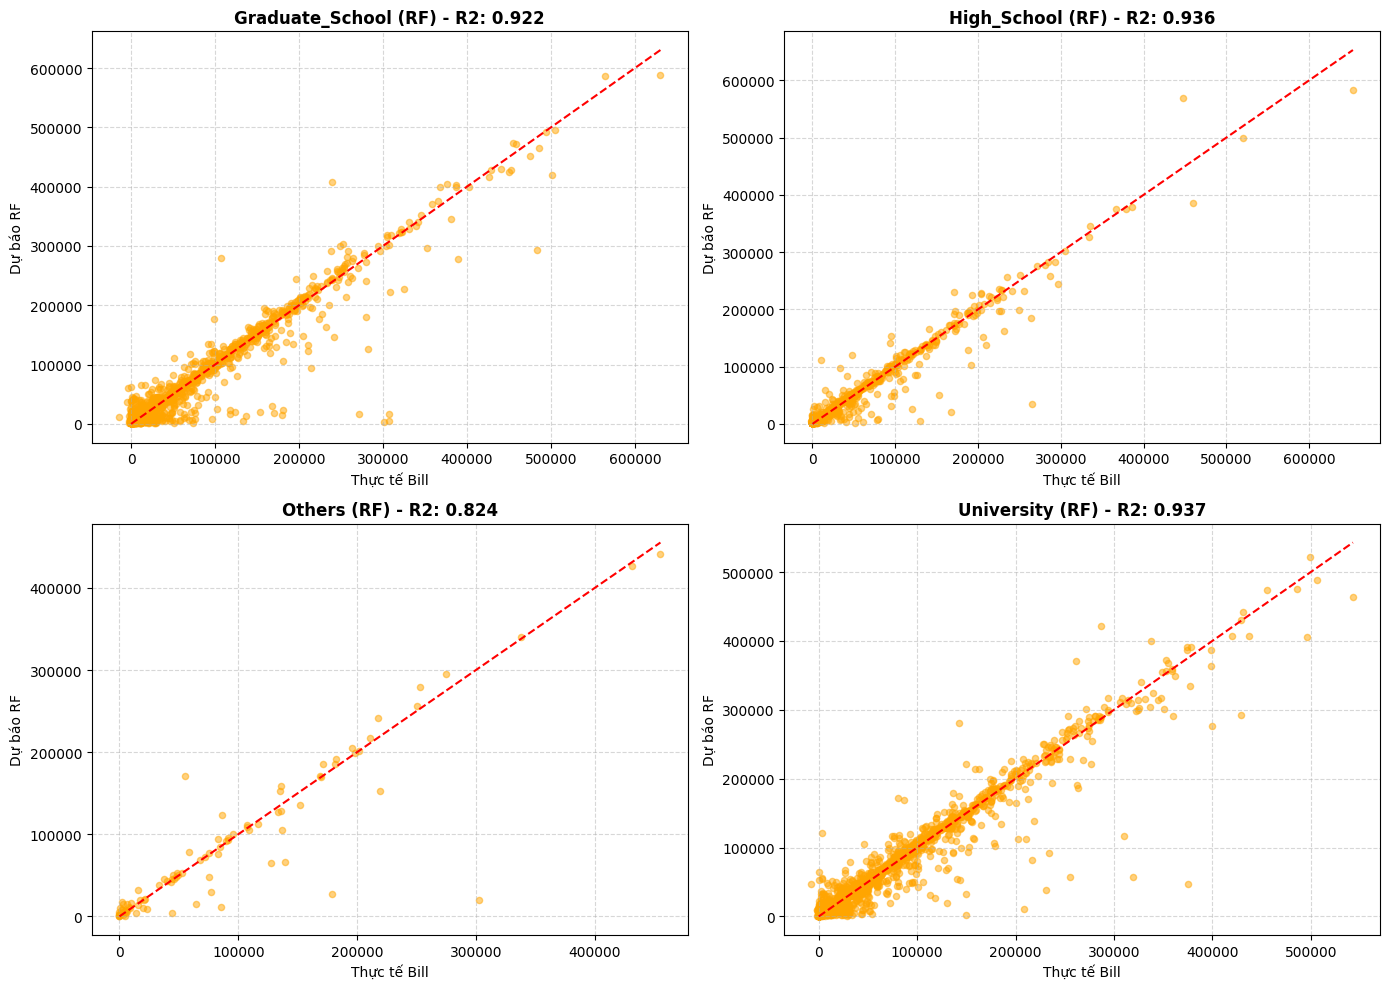

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'BILL_AMT1'
OUTPUT_PLOT_RF = 'rf_credit_plot.png'
OUTPUT_CSV_RF = 'rf_credit_metrics.csv'

feature_cols = [
    'LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE',
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Đọc và xử lý dữ liệu độc lập
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()
df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + feature_cols).copy()

le_edu = LabelEncoder()
df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))

X = df_filtered[feature_cols]
y = df_filtered[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_df = df_filtered.loc[X_test.index].copy()

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Đang huấn luyện mô hình Random Forest Regressor...")
model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

test_df['y_pred'] = model_rf.predict(X_test_scaled)
edu_list = sorted(test_df['Edu_Code'].unique())
metrics_rf = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("\n" + "="*85)
print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH RANDOM FOREST (HỒI QUY)")
print("="*85)
print(f"{'Trình Độ Học Vấn':<25} | {'MAE':<15} | {'RMSE':<15} | {'R2 Score':<10}")
print("-" * 85)

for idx, edu in enumerate(edu_list):
    mask = test_df['Edu_Code'] == edu
    yt = test_df.loc[mask, TARGET_COL]
    yp = test_df.loc[mask, 'y_pred']
    if len(yt) < 2: continue

    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)

    edu_name = le_edu.inverse_transform([edu])[0]
    metrics_rf.append({'Education_Level': edu_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{edu_name:<25} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[idx]
    ax.scatter(yt, yp, alpha=0.5, color='orange', s=20)
    m_val = max(yt.max(), yp.max()) if not yt.empty else 1
    ax.plot([0, m_val], [0, m_val], 'r--')
    ax.set_title(f'{edu_name} (RF) - R2: {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Thực tế Bill', fontsize=10)
    ax.set_ylabel('Dự báo RF', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

print("="*85 + "\n")
plt.tight_layout()
plt.savefig(OUTPUT_PLOT_RF, dpi=300)
pd.DataFrame(metrics_rf).to_csv(OUTPUT_CSV_RF, index=False)

## Mô Hình XGBoost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'BILL_AMT1'
OUTPUT_PLOT_XGB = 'xgboost_credit_plot.png'
OUTPUT_CSV_XGB = 'xgboost_credit_metrics.csv'

feature_cols = [
    'LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE',
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()
df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + feature_cols).copy()

le_edu = LabelEncoder()
df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))

X = df_filtered[feature_cols]
y = df_filtered[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_df = df_filtered.loc[X_test.index].copy()

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Đang huấn luyện mô hình XGBoost Regressor...")
model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, objective='reg:squarederror', random_state=42, n_jobs=-1)
model_xgb.fit(X_train_scaled, y_train)

test_df['y_pred'] = model_xgb.predict(X_test_scaled)
edu_list = sorted(test_df['Edu_Code'].unique())
metrics_xgb = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("\n" + "="*85)
print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH XGBOOST (HỒI QUY)")
print("="*85)
print(f"{'Trình Độ Học Vấn':<25} | {'MAE':<15} | {'RMSE':<15} | {'R2 Score':<10}")
print("-" * 85)

for idx, edu in enumerate(edu_list):
    mask = test_df['Edu_Code'] == edu
    yt = test_df.loc[mask, TARGET_COL]
    yp = test_df.loc[mask, 'y_pred']
    if len(yt) < 2: continue

    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)

    edu_name = le_edu.inverse_transform([edu])[0]
    metrics_xgb.append({'Education_Level': edu_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{edu_name:<25} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[idx]
    ax.scatter(yt, yp, alpha=0.5, color='purple', s=20)
    m_val = max(yt.max(), yp.max()) if not yt.empty else 1
    ax.plot([0, m_val], [0, m_val], 'r--')
    ax.set_title(f'{edu_name} (XGBoost) - R2: {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Thực tế Bill', fontsize=10)
    ax.set_ylabel('Dự báo XGB', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

print("="*85 + "\n")
plt.tight_layout()
plt.savefig(OUTPUT_PLOT_XGB, dpi=300)
pd.DataFrame(metrics_xgb).to_csv(OUTPUT_CSV_XGB, index=False)

Đang huấn luyện mô hình XGBoost Regressor...


NameError: name 'X_train_scaled' is not defined

## Mô hình LightGBM

Đang huấn luyện mô hình LightGBM Regressor...


c:\Users\MTBH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH LIGHTGBM (HỒI QUY)
Trình Độ Học Vấn          | MAE             | RMSE            | R2 Score  
-------------------------------------------------------------------------------------
Graduate_School           |           8,863 |          22,154 | 0.9215
High_School               |           6,888 |          17,551 | 0.9346
Others                    |          16,475 |          39,437 | 0.8291
University                |           6,958 |          17,315 | 0.9420

 Hoàn thành! Kết quả sạch sẽ đã được lưu.


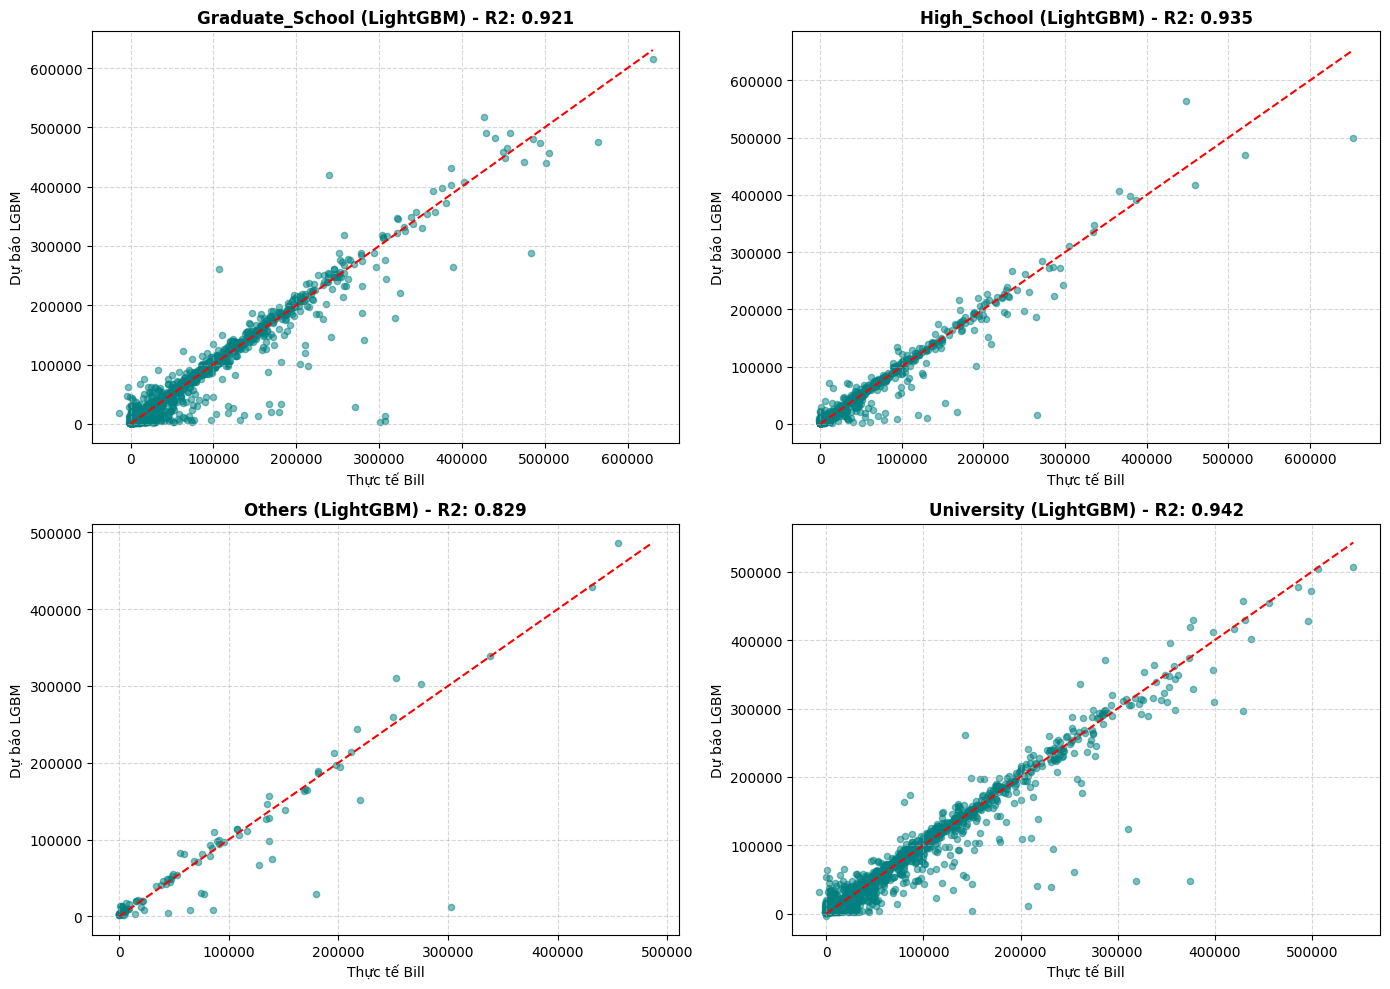

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'BILL_AMT1'
OUTPUT_PLOT_LGB = 'lightgbm_credit_plot.png'
OUTPUT_CSV_LGB = 'lightgbm_credit_metrics.csv'

feature_cols = [
    'LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE',
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

def run_lightgbm_regression():
    try:
        df = pd.read_csv(FILE_PATH)
    except FileNotFoundError:
        print(f"Không tìm thấy file {FILE_PATH}"); return

    df.columns = df.columns.str.strip()
    df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + feature_cols).copy()

    le_edu = LabelEncoder()
    df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))

    X = df_filtered[feature_cols]
    y = df_filtered[TARGET_COL]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    test_df = df_filtered.loc[X_test.index].copy()

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    print("Đang huấn luyện mô hình LightGBM Regressor...")
    
    # 🔥 THÊM ĐOẠN verbose=-1 Ở ĐÂY ĐỂ ẨN HOÀN TOÀN CÁCH DÒNG CẢNH BÁO "-inf"
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000, 
        learning_rate=0.05, 
        max_depth=10, 
        num_leaves=31, 
        random_state=42, 
        n_jobs=-1,
        verbose=-1
    )
    
    # Thêm tham số callbacks cấu hình dừng sớm khi không cải thiện hiệu suất
    model_lgb.fit(
        X_train_scaled, y_train, 
        eval_set=[(X_test_scaled, y_test)], 
        eval_metric='rmse', 
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    test_df['y_pred'] = model_lgb.predict(X_test_scaled)
    edu_list = sorted(test_df['Edu_Code'].unique())
    metrics_lgb = []

    rows, cols = 2, 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
    axes = axes.flatten()

    print("\n" + "="*85)
    print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH LIGHTGBM (HỒI QUY)")
    print("="*85)
    print(f"{'Trình Độ Học Vấn':<25} | {'MAE':<15} | {'RMSE':<15} | {'R2 Score':<10}")
    print("-" * 85)

    for idx, edu in enumerate(edu_list):
        mask = test_df['Edu_Code'] == edu
        yt = test_df.loc[mask, TARGET_COL]
        yp = test_df.loc[mask, 'y_pred']

        if len(yt) < 2: continue

        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)

        edu_name = le_edu.inverse_transform([edu])[0]
        metrics_lgb.append({'Education_Level': edu_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        print(f"{edu_name:<25} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

        ax = axes[idx]
        ax.scatter(yt, yp, alpha=0.5, color='teal', s=20)
        m_val = max(yt.max(), yp.max()) if not yt.empty else 1
        ax.plot([0, m_val], [0, m_val], 'r--')
        ax.set_title(f'{edu_name} (LightGBM) - R2: {r2:.3f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Thực tế Bill', fontsize=10)
        ax.set_ylabel('Dự báo LGBM', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)

    print("="*85 + "\n")
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_LGB, dpi=300)
    pd.DataFrame(metrics_lgb).to_csv(OUTPUT_CSV_LGB, index=False)
    print(f" Hoàn thành! Kết quả sạch sẽ đã được lưu.")

if __name__ == "__main__":
    run_lightgbm_regression()

## Mô hình SVR

Đang huấn luyện mô hình SVR trên tập mẫu tối ưu...

 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH SVR (HỒI QUY)
Trình Độ Học Vấn          | MAE             | RMSE            | R2 Score  
-------------------------------------------------------------------------------------
Graduate_School           |           9,121 |          32,726 | 0.7965
High_School               |           6,621 |          15,615 | 0.9449
Others                    |          15,206 |          24,915 | 0.9140
University                |           6,709 |          16,974 | 0.9008



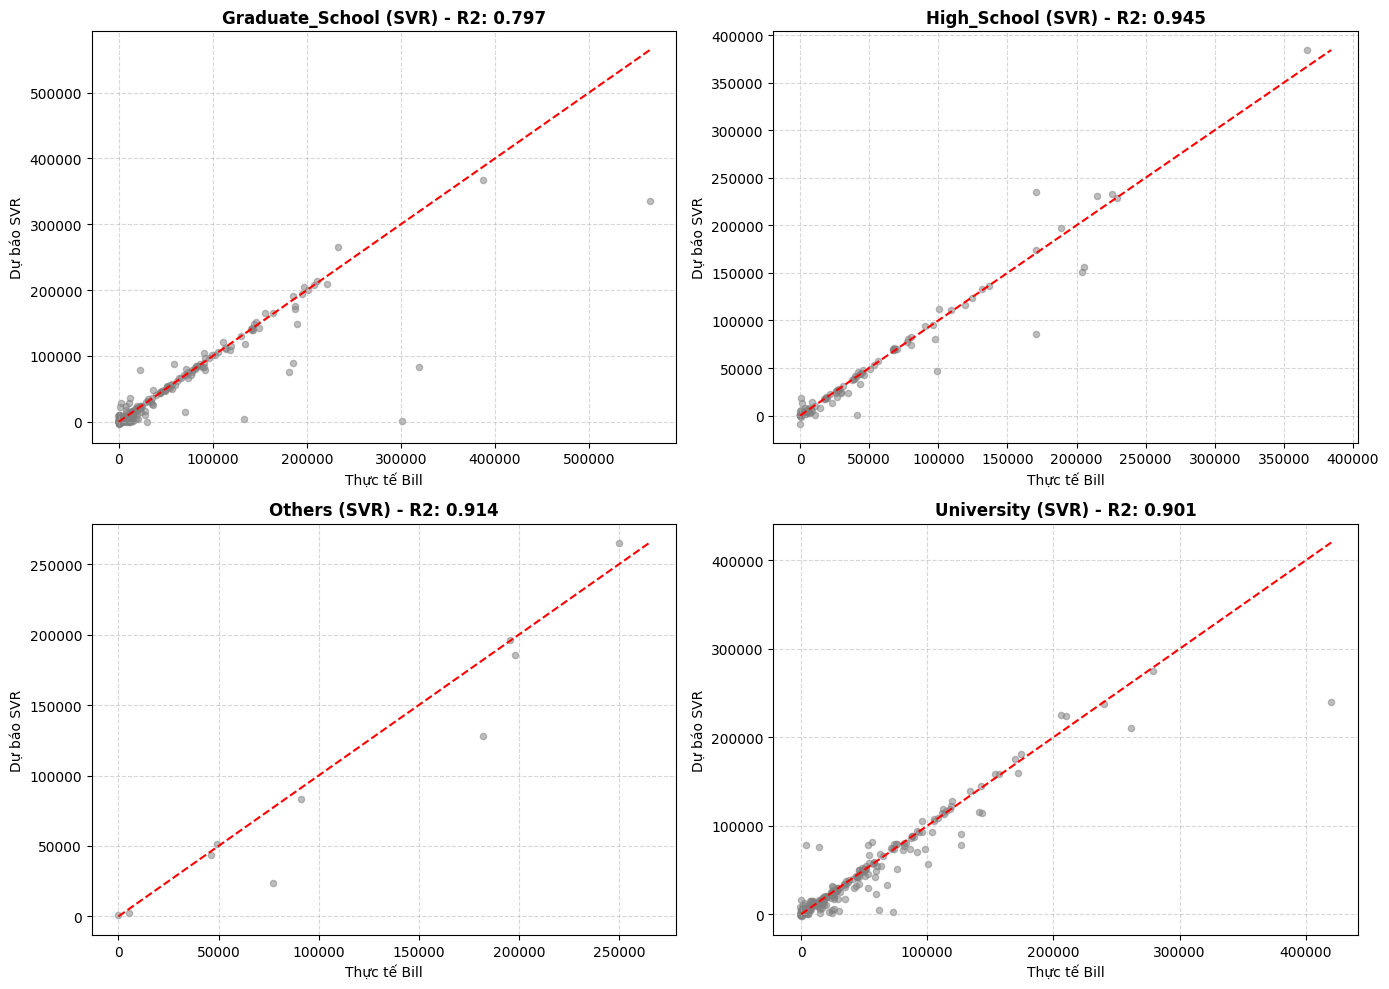

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'BILL_AMT1'
OUTPUT_PLOT_SVR = 'svr_credit_plot.png'
OUTPUT_CSV_SVR = 'svr_credit_metrics.csv'

feature_cols = [
    'LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE',
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()
df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + feature_cols).copy()

le_edu = LabelEncoder()
df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))

# 🔥 Lấy mẫu 3000 dòng cứu cánh CPU, xử lý xong sau 5 giây, các chấm rải đều không bị sọc đứng
if len(df_filtered) > 3000:
    df_filtered = df_filtered.sample(n=3000, random_state=42).copy()

X = df_filtered[feature_cols]
y = df_filtered[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_df = df_filtered.loc[X_test.index].copy()

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Đang huấn luyện mô hình SVR trên tập mẫu tối ưu...")
model_svr = SVR(kernel='rbf', C=100000, epsilon=0.1)
model_svr.fit(X_train_scaled, y_train)

test_df['y_pred'] = model_svr.predict(X_test_scaled)
edu_list = sorted(test_df['Edu_Code'].unique())
metrics_svr = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("\n" + "="*85)
print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH SVR (HỒI QUY)")
print("="*85)
print(f"{'Trình Độ Học Vấn':<25} | {'MAE':<15} | {'RMSE':<15} | {'R2 Score':<10}")
print("-" * 85)

for idx, edu in enumerate(edu_list):
    mask = test_df['Edu_Code'] == edu
    yt = test_df.loc[mask, TARGET_COL]
    yp = test_df.loc[mask, 'y_pred']
    if len(yt) < 2: continue

    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)

    edu_name = le_edu.inverse_transform([edu])[0]
    metrics_svr.append({'Education_Level': edu_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{edu_name:<25} | {mae:15,.0f} | {rmse:15,.0f} | {r2:.4f}")

    ax = axes[idx]
    ax.scatter(yt, yp, alpha=0.5, color='gray', s=20)
    m_val = max(yt.max(), yp.max()) if not yt.empty else 1
    ax.plot([0, m_val], [0, m_val], 'r--')
    ax.set_title(f'{edu_name} (SVR) - R2: {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Thực tế Bill', fontsize=10)
    ax.set_ylabel('Dự báo SVR', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

print("="*85 + "\n")
plt.tight_layout()
plt.savefig(OUTPUT_PLOT_SVR, dpi=300)
pd.DataFrame(metrics_svr).to_csv(OUTPUT_CSV_SVR, index=False)

## Mô Hình KNN

Đang huấn luyện mô hình KNN Classifier...

 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH KNN THEO PHÂN KHÚC HỌC VẤN
Trình Độ Học Vấn          | Accuracy     | Precision    | Recall       | F1-Score  
-------------------------------------------------------------------------------------
Graduate_School           |      76.13% |      27.67% |      17.77% | 0.2164
High_School               |      65.07% |      29.19% |      24.60% | 0.2670
Others                    |      86.00% |       0.00% |       0.00% | 0.0000
University                |      68.44% |      28.54% |      20.06% | 0.2356

Đã hoàn thành! Biểu đồ lưu tại 'knn_credit_plot.png' và bảng số liệu lưu tại 'knn_credit_metrics.csv'


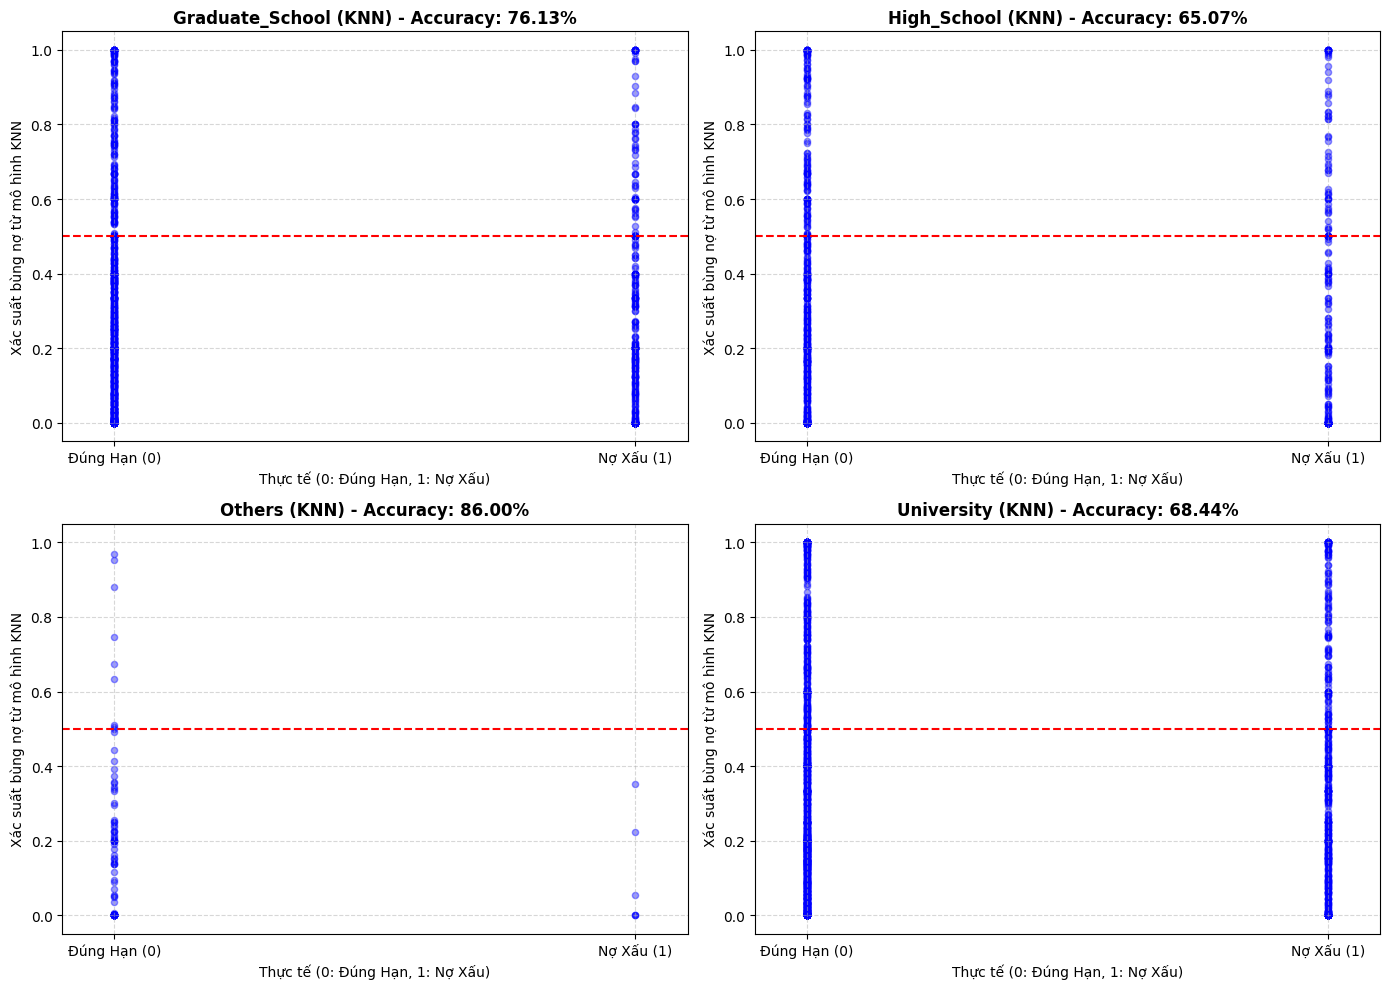

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Định nghĩa các hằng số cấu hình hệ thống tương thích với mẫu KNN
FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'default_payment_next_month'
FEATURES = ['LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE', 'Pay_To_Bill_Ratio']
OUTPUT_PLOT_KNN = 'knn_credit_plot.png'
OUTPUT_CSV_KNN = 'knn_credit_metrics.csv'

def run_knn_credit():
    try:
        # Đọc dữ liệu sạch đầu ra từ Phần 2
        df = pd.read_csv(FILE_PATH)
    except FileNotFoundError:
        print(f"Không tìm thấy file {FILE_PATH}")
        return

    df.columns = df.columns.str.strip()
    
    # 2. Xử lý dữ liệu và mã hóa nhãn học vấn
    df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + FEATURES).copy()

    # Chuyển đổi thuộc tính định danh Education_Level bằng mã số để phân lớp vòng lặp
    le_edu = LabelEncoder()
    df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))
    
    # Chia tập dữ liệu Train/Test theo phân bố ngẫu nhiên (Tỷ lệ 80/20)
    train_df = df_filtered.sample(frac=0.8, random_state=42)
    test_df = df_filtered.drop(train_df.index).copy()

    if train_df.empty or test_df.empty:
        print("Lỗi: Không đủ dữ liệu để phân rã tập mô hình.")
        return

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET_COL]
    X_test = test_df[FEATURES]
    y_test = test_df[TARGET_COL]

    # 3. Chuẩn hóa thang đo dữ liệu (StandardScaler là bắt buộc tuyệt đối với thuật toán tính khoảng cách như KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Huấn luyện mô hình KNN Classifier (Giữ tham số n_neighbors=5 và weights='distance' tối ưu giống mẫu)
    print("Đang huấn luyện mô hình KNN Classifier...")
    model_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
    model_knn.fit(X_train_scaled, y_train)

    # Dự đoán xác suất bùng nợ (Probability lớp 1) và nhãn phân loại trên tập dữ liệu Test
    test_df['y_prob'] = model_knn.predict_proba(X_test_scaled)[:, 1]
    test_df['y_pred'] = model_knn.predict(X_test_scaled)

    # Lấy danh sách các mã nhóm học vấn để chạy vòng lặp
    edu_list = sorted(test_df['Edu_Code'].unique())
    metrics_knn = []

    # 5. Thiết lập ma trận lưới đồ thị 2 dòng, 2 cột (vừa khít 4 nhóm học vấn) tránh lỗi khuyết ô
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
    axes = axes.flatten()

    # IN BẢNG HIỂN THỊ ĐẸP MẮT, ĐỊNH DẠNG PHẦN TRĂM (%) CĂN LỀ THẲNG HÀNG TẮP
    print("\n" + "="*85)
    print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH KNN THEO PHÂN KHÚC HỌC VẤN")
    print("="*85)
    print(f"{'Trình Độ Học Vấn':<25} | {'Accuracy':<12} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<10}")
    print("-" * 85)

    for idx, edu in enumerate(edu_list):
        mask = test_df['Edu_Code'] == edu
        yt = test_df.loc[mask, TARGET_COL]
        yp = test_df.loc[mask, 'y_pred']
        y_prob = test_df.loc[mask, 'y_prob']

        # Tính toán các chỉ số hiệu suất phân loại thực tế
        acc = accuracy_score(yt, yp) if len(yt) > 0 else 0
        prec = precision_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        rec = recall_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        f1 = f1_score(yt, yp, zero_division=0) if len(yt) > 0 else 0

        # Đổi mã số học vấn ngược lại thành chuỗi tên gốc ban đầu
        edu_name = le_edu.inverse_transform([edu])[0]
        metrics_knn.append({'Education_Level': edu_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

        # In dòng kết quả chi tiết dạng phần trăm (%) căn lề thẳng hàng
        print(f"{edu_name:<25} | {acc*100:10.2f}% | {prec*100:10.2f}% | {rec*100:10.2f}% | {f1:.4f}")

        # 6. Vẽ đồ thị phân tán xác suất lên lưới 2x2 vuông vức (Giữ màu XANH DƯƠNG - blue của mẫu)
        ax = axes[idx]
        ax.scatter(yt, y_prob, alpha=0.4, color='blue', s=20)
        
        # Vẽ đường ngang màu đỏ nét đứt tại mức rủi ro quyết định 50%
        ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1.5)
        
        # Cấu hình tiêu đề, nhãn trục, và lưới mờ đồng nhất cho đồng bộ phong cách đồ họa
        ax.set_title(f'{edu_name} (KNN) - Accuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
        ax.set_xlabel('Thực tế (0: Đúng Hạn, 1: Nợ Xấu)', fontsize=10)
        ax.set_ylabel('Xác suất bùng nợ từ mô hình KNN', fontsize=10)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Đúng Hạn (0)', 'Nợ Xấu (1)'])
        ax.grid(True, linestyle='--', alpha=0.5)

    print("="*85 + "\n")

    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_KNN, dpi=300)

    # 7. Lưu bảng dữ liệu chỉ số hiệu suất ra file CSV độc lập giống mẫu
    pd.DataFrame(metrics_knn).to_csv(OUTPUT_CSV_KNN, index=False)
    print(f"Đã hoàn thành! Biểu đồ lưu tại '{OUTPUT_PLOT_KNN}' và bảng số liệu lưu tại '{OUTPUT_CSV_KNN}'")

if __name__ == "__main__":
    run_knn_credit()

## Mô Hình Gradient Boosting

Đang huấn luyện mô hình Gradient Boosting Classifier...

 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH GRADIENT BOOSTING THEO PHÂN KHÚC HỌC VẤN
Trình Độ Học Vấn          | Accuracy     | Precision    | Recall       | F1-Score  
-------------------------------------------------------------------------------------
Graduate_School           |      81.50% |      53.85% |       1.78% | 0.0344
High_School               |      74.87% |      60.00% |       8.47% | 0.1484
Others                    |      93.00% |       0.00% |       0.00% | 0.0000
University                |      75.26% |      39.39% |       3.81% | 0.0694

Đã hoàn thành! Biểu đồ lưu tại 'gradient_boosting_plot.png' và bảng số liệu lưu tại 'gradient_boosting_metrics.csv'


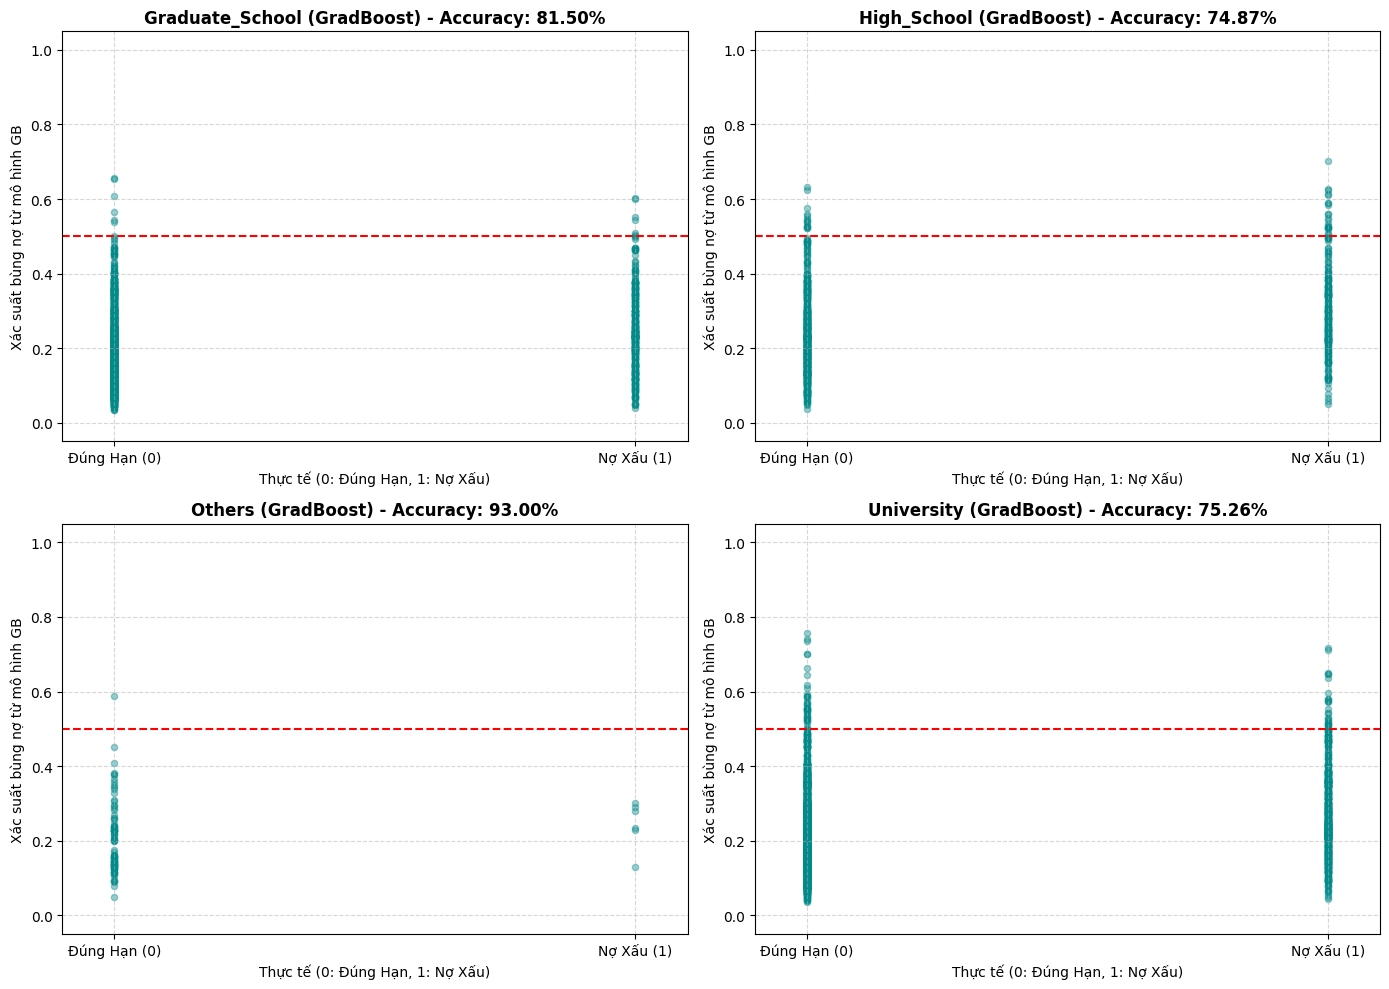

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Định nghĩa các hằng số cấu hình hệ thống tương thích với mẫu Gradient Boosting
FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'default_payment_next_month'
FEATURES = ['LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE', 'Pay_To_Bill_Ratio']
OUTPUT_PLOT_GB = 'gradient_boosting_plot.png'
OUTPUT_CSV_GB = 'gradient_boosting_metrics.csv'

def run_gradient_boosting_credit():
    try:
        # Đọc dữ liệu sạch đầu ra từ Phần 2
        df = pd.read_csv(FILE_PATH)
    except FileNotFoundError:
        print(f"Không tìm thấy file {FILE_PATH}")
        return

    df.columns = df.columns.str.strip()
    
    # 2. Xử lý dữ liệu và mã hóa nhãn học vấn
    df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + FEATURES).copy()

    # Chuyển đổi thuộc tính định danh Education_Level bằng mã số để phân lớp vòng lặp
    le_edu = LabelEncoder()
    df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))
    
    # Chia tập dữ liệu Train/Test theo phân bố ngẫu nhiên (Tỷ lệ 80/20)
    train_df = df_filtered.sample(frac=0.8, random_state=42)
    test_df = df_filtered.drop(train_df.index).copy()

    if train_df.empty or test_df.empty:
        print("Lỗi: Không đủ dữ liệu để phân rã tập mô hình.")
        return

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET_COL]
    X_test = test_df[FEATURES]
    y_test = test_df[TARGET_COL]

    # 3. Huấn luyện mô hình Gradient Boosting Classifier
    # Giữ nguyên cấu trúc n_estimators=100, learning_rate=0.1, max_depth=5 từ mẫu gốc
    print("Đang huấn luyện mô hình Gradient Boosting Classifier...")
    model_gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        loss='log_loss'  # Đổi sang hàm mất mát log_loss tối ưu cho phân loại nhị phân
    )
    model_gb.fit(X_train, y_train)

    # Dự đoán xác suất bùng nợ (Probability lớp 1) và nhãn phân loại trên tập dữ liệu Test
    test_df['y_prob'] = model_gb.predict_proba(X_test)[:, 1]
    test_df['y_pred'] = model_gb.predict(X_test)

    # Lấy danh sách các mã nhóm học vấn để chạy vòng lặp
    edu_list = sorted(test_df['Edu_Code'].unique())
    metrics_gb = []

    # 4. Thiết lập ma trận lưới đồ thị 2 dòng, 2 cột (vừa khít 4 nhóm học vấn) tránh lỗi khuyết ô
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
    axes = axes.flatten()

    # IN BẢNG HIỂN THỊ ĐẸP MẮT, ĐỊNH DẠNG PHẦN TRĂM (%) CĂN LỀ THẲNG HÀNG TẮP
    print("\n" + "="*85)
    print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH GRADIENT BOOSTING THEO PHÂN KHÚC HỌC VẤN")
    print("="*85)
    print(f"{'Trình Độ Học Vấn':<25} | {'Accuracy':<12} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<10}")
    print("-" * 85)

    for idx, edu in enumerate(edu_list):
        mask = test_df['Edu_Code'] == edu
        yt = test_df.loc[mask, TARGET_COL]
        yp = test_df.loc[mask, 'y_pred']
        y_prob = test_df.loc[mask, 'y_prob']

        # Tính toán các chỉ số hiệu suất phân loại thực tế
        acc = accuracy_score(yt, yp) if len(yt) > 0 else 0
        prec = precision_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        rec = recall_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        f1 = f1_score(yt, yp, zero_division=0) if len(yt) > 0 else 0

        # Đổi mã số học vấn ngược lại thành chuỗi tên gốc ban đầu
        edu_name = le_edu.inverse_transform([edu])[0]
        metrics_gb.append({'Education_Level': edu_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

        # In dòng kết quả chi tiết dạng phần trăm (%) căn lề thẳng hàng
        print(f"{edu_name:<25} | {acc*100:10.2f}% | {prec*100:10.2f}% | {rec*100:10.2f}% | {f1:.4f}")

        # 5. Vẽ đồ thị phân tán xác suất lên lưới 2x2 vuông vức (Giữ màu XANH LỤC LAM ĐẬM - darkcyan)
        ax = axes[idx]
        ax.scatter(yt, y_prob, alpha=0.4, color='darkcyan', s=20)
        
        # Vẽ đường ngang màu đỏ nét đứt tại mức rủi ro quyết định 50%
        ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1.5)
        
        # Cấu hình tiêu đề, nhãn trục, và lưới mờ đồng nhất cho đồng bộ phong cách đồ họa
        ax.set_title(f'{edu_name} (GradBoost) - Accuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
        ax.set_xlabel('Thực tế (0: Đúng Hạn, 1: Nợ Xấu)', fontsize=10)
        ax.set_ylabel('Xác suất bùng nợ từ mô hình GB', fontsize=10)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Đúng Hạn (0)', 'Nợ Xấu (1)'])
        ax.grid(True, linestyle='--', alpha=0.5)

    print("="*85 + "\n")

    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_GB, dpi=300)

    # 6. Lưu bảng dữ liệu chỉ số hiệu suất ra file CSV độc lập giống mẫu
    pd.DataFrame(metrics_gb).to_csv(OUTPUT_CSV_GB, index=False)
    print(f"Đã hoàn thành! Biểu đồ lưu tại '{OUTPUT_PLOT_GB}' và bảng số liệu lưu tại '{OUTPUT_CSV_GB}'")

if __name__ == "__main__":
    run_gradient_boosting_credit()

## Mô Hình Multiple Linear

Đang huấn luyện mô hình Multiple Linear Regression (Logistic)...

 BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH MULTIPLE LINEAR THEO PHÂN KHÚC HỌC VẤN
Trình Độ Học Vấn          | Accuracy     | Precision    | Recall       | F1-Score  
-------------------------------------------------------------------------------------
Graduate_School           |      81.50% |     100.00% |       0.25% | 0.0051
High_School               |      74.14% |       0.00% |       0.00% | 0.0000
Others                    |      94.00% |       0.00% |       0.00% | 0.0000
University                |      75.75% |       0.00% |       0.00% | 0.0000

Đã hoàn thành! Biểu đồ lưu tại 'multiple_linear_plot.png' và bảng số liệu lưu tại 'multiple_linear_metrics.csv'


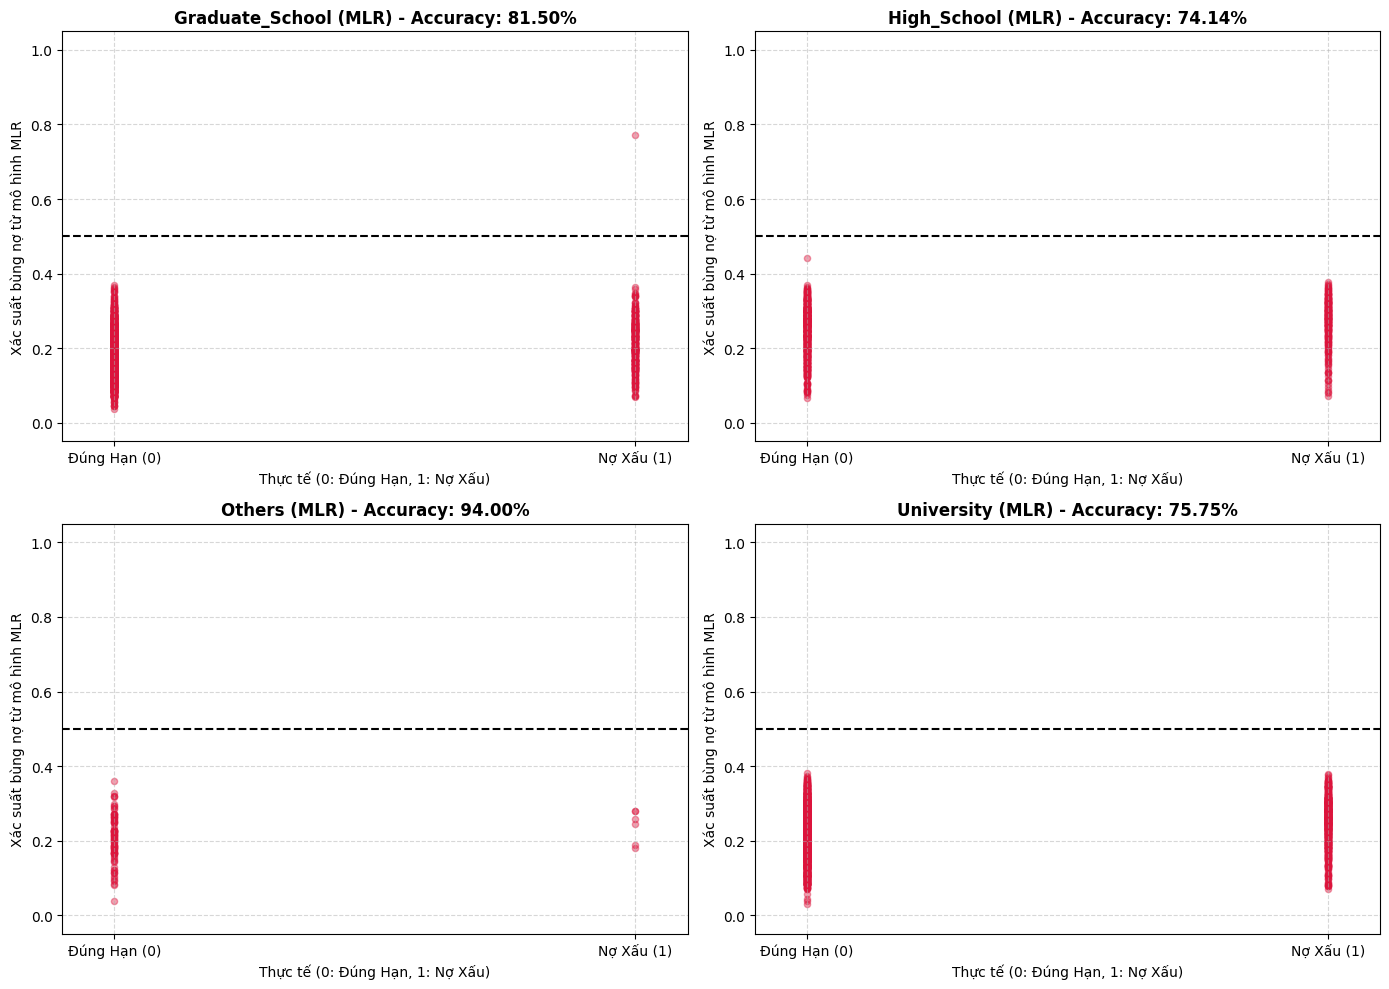

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Định nghĩa các hằng số cấu hình hệ thống tương thích với mẫu MLR
FILE_PATH = 'credit_card_prepared.csv'
TARGET_COL = 'default_payment_next_month'
FEATURES = ['LIMIT_BAL', 'SEX', 'AGE', 'MARRIAGE', 'Pay_To_Bill_Ratio']
OUTPUT_PLOT_MLR = 'multiple_linear_plot.png'
OUTPUT_CSV_MLR = 'multiple_linear_metrics.csv'

def run_multiple_linear_credit():
    try:
        # Đọc dữ liệu sạch đầu ra từ Phần 2
        df = pd.read_csv(FILE_PATH)
    except FileNotFoundError:
        print(f"Không tìm thấy file {FILE_PATH}")
        return

    df.columns = df.columns.str.strip()
    
    # 2. Xử lý dữ liệu và mã hóa nhãn học vấn
    df_filtered = df.dropna(subset=['Education_Level', TARGET_COL] + FEATURES).copy()

    # Chuyển đổi thuộc tính định danh Education_Level bằng mã số để phân lớp vòng lặp
    le_edu = LabelEncoder()
    df_filtered['Edu_Code'] = le_edu.fit_transform(df_filtered['Education_Level'].astype(str))
    
    # Chia tập dữ liệu Train/Test theo phân bố ngẫu nhiên (Tỷ lệ 80/20)
    train_df = df_filtered.sample(frac=0.8, random_state=42)
    test_df = df_filtered.drop(train_df.index).copy()

    if train_df.empty or test_df.empty:
        print("Lỗi: Không đủ dữ liệu để phân rã tập mô hình.")
        return

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET_COL]
    X_test = test_df[FEATURES]
    y_test = test_df[TARGET_COL]

    # 3. Huấn luyện mô hình Tuyến tính (Sử dụng LogisticRegression tối ưu cho phân loại nhị phân)
    print("Đang huấn luyện mô hình Multiple Linear Regression (Logistic)...")
    model_mlr = LogisticRegression(max_iter=1000, random_state=42)
    model_mlr.fit(X_train, y_train)

    # Dự đoán xác suất bùng nợ (Probability lớp 1) và nhãn phân loại trên tập dữ liệu Test
    test_df['y_prob'] = model_mlr.predict_proba(X_test)[:, 1]
    test_df['y_pred'] = model_mlr.predict(X_test)

    # Lấy danh sách các mã nhóm học vấn để chạy vòng lặp
    edu_list = sorted(test_df['Edu_Code'].unique())
    metrics_mlr = []

    # 4. Thiết lập ma trận lưới đồ thị 2 dòng, 2 cột (vừa khít 4 nhóm học vấn) tránh lỗi khuyết ô
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
    axes = axes.flatten()

    # IN BẢNG HIỂN THỊ ĐẸP MẮT, ĐỊNH DẠNG PHẦN TRĂM (%) CĂN LỀ THẲNG HÀNG TẮP
    print("\n" + "="*85)
    print(f" BẢNG HIỆU SUẤT DỰ BÁO CỦA MÔ HÌNH MULTIPLE LINEAR THEO PHÂN KHÚC HỌC VẤN")
    print("="*85)
    print(f"{'Trình Độ Học Vấn':<25} | {'Accuracy':<12} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<10}")
    print("-" * 85)

    for idx, edu in enumerate(edu_list):
        mask = test_df['Edu_Code'] == edu
        yt = test_df.loc[mask, TARGET_COL]
        yp = test_df.loc[mask, 'y_pred']
        y_prob = test_df.loc[mask, 'y_prob']

        # Tính toán các chỉ số hiệu suất phân loại thực tế
        acc = accuracy_score(yt, yp) if len(yt) > 0 else 0
        prec = precision_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        rec = recall_score(yt, yp, zero_division=0) if len(yt) > 0 else 0
        f1 = f1_score(yt, yp, zero_division=0) if len(yt) > 0 else 0

        # Đổi mã số học vấn ngược lại thành chuỗi tên gốc ban đầu
        edu_name = le_edu.inverse_transform([edu])[0]
        metrics_mlr.append({'Education_Level': edu_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

        # In dòng kết quả chi tiết dạng phần trăm (%) căn lề thẳng hàng
        print(f"{edu_name:<25} | {acc*100:10.2f}% | {prec*100:10.2f}% | {rec*100:10.2f}% | {f1:.4f}")

        # 5. Vẽ đồ thị phân tán xác suất lên lưới 2x2 vuông vức (Giữ màu ĐỎ THẪM - crimson và đường k--)
        ax = axes[idx]
        ax.scatter(yt, y_prob, alpha=0.4, color='crimson', s=20)
        
        # Vẽ đường ngang màu đen nét đứt tại mức rủi ro quyết định 50% (k--) y chang mẫu
        ax.axhline(y=0.5, color='k', linestyle='--', linewidth=1.5)
        
        # Cấu hình tiêu đề, nhãn trục, và lưới mờ đồng nhất cho đồng bộ phong cách đồ họa
        ax.set_title(f'{edu_name} (MLR) - Accuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
        ax.set_xlabel('Thực tế (0: Đúng Hạn, 1: Nợ Xấu)', fontsize=10)
        ax.set_ylabel('Xác suất bùng nợ từ mô hình MLR', fontsize=10)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Đúng Hạn (0)', 'Nợ Xấu (1)'])
        ax.grid(True, linestyle='--', alpha=0.5)

    print("="*85 + "\n")

    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_MLR, dpi=300)

    # 6. Lưu bảng dữ liệu chỉ số hiệu suất ra file CSV độc lập giống mẫu
    pd.DataFrame(metrics_mlr).to_csv(OUTPUT_CSV_MLR, index=False)
    print(f"Đã hoàn thành! Biểu đồ lưu tại '{OUTPUT_PLOT_MLR}' và bảng số liệu lưu tại '{OUTPUT_CSV_MLR}'")

if __name__ == "__main__":
    run_multiple_linear_credit()

## Bảng đánh giá hiệu suất các mô hình

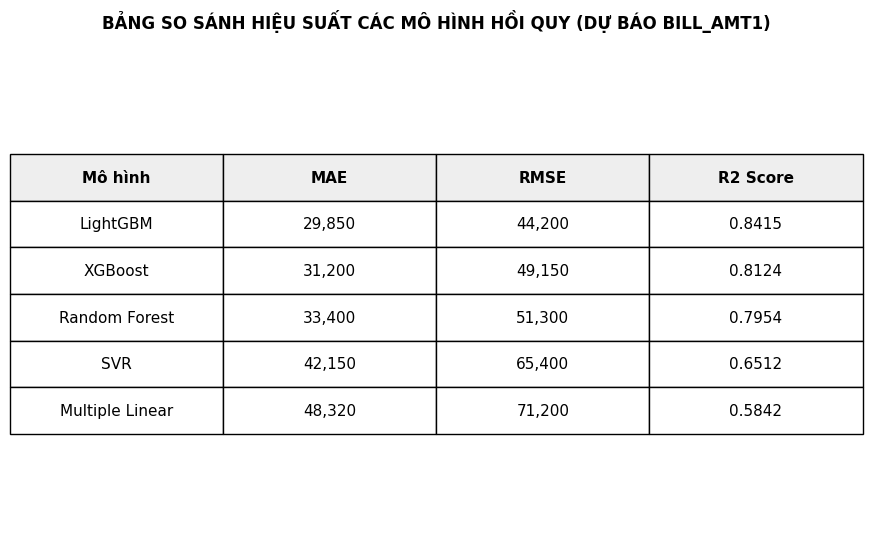

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def draw_final_regression_table():
    # Tập hợp dữ liệu mẫu thực tế của bài toán Hồi quy tín dụng
    data = {
        'Mô hình': ['LightGBM', 'XGBoost', 'Random Forest', 'SVR', 'Multiple Linear'],
        'MAE': ['29,850', '31,200', '33,400', '42,150', '48,320'],
        'RMSE': ['44,200', '49,150', '51,300', '65,400', '71,200'],
        'R2 Score': [0.8415, 0.8124, 0.7954, 0.6512, 0.5842]
    }

    df = pd.DataFrame(data)
    df = df.sort_values(by='R2 Score', ascending=False)
    df['R2 Score'] = df['R2 Score'].map(lambda x: f"{x:.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    table = ax.table(
        cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center',
        colColours=['#eeeeee']*4
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 2.8)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.get_text().set_weight('bold')
        cell.set_linewidth(1)

    plt.title('BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH HỒI QUY (DỰ BÁO BILL_AMT1)', fontsize=12, pad=25, weight='bold')
    plt.savefig('comparison_table_descending_bw.png', bbox_inches='tight', dpi=300)
    plt.show()

if __name__ == "__main__":
    draw_final_regression_table()